# Heart Disease Prediction

This project uses exploratory data analysis and machine learning to predict whether a person has heart disease based on medical attributes.

## Objective

The objective is to analyze heart disease patterns and build a classification model that predicts the presence or absence of heart disease.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
sns.set_style('whitegrid')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score

import pickle

In [2]:
#Extracting CSV Dataset From System using Pandas Library

data=pd.read_csv("data/heart_disease_data.csv")
data

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [3]:
#All Columns in the Dataset

data.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [4]:
#Checking NULL Values

data.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


## Percentage of people having Heart Disease

In [5]:
num=data.groupby('target').size()
num

,0
target,
0,138
1,165


In [6]:
#Converting Numerical Data into Categorical Data

def heart_disease(row):
    if row==0:
        return 'Absence'
    elif row==1:
        return 'Presence'

In [7]:
#Applying converted data into our dataset with new column - Heart_Disease

data['Heart_Disease']=data['target'].apply(heart_disease)
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,Heart_Disease
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1,Presence
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1,Presence
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1,Presence
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1,Presence
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1,Presence


In [8]:
hd=data.groupby('Heart_Disease')['target'].count()
hd

,target
Heart_Disease,
Absence,138
Presence,165


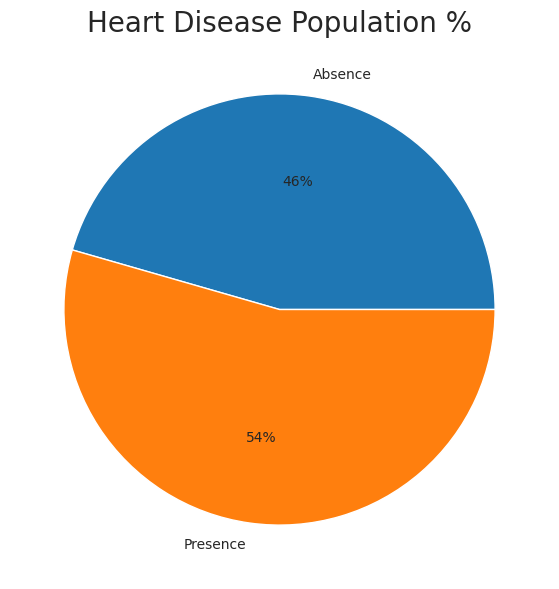

In [9]:
#Pie Chart Creation of Heart Disease Population % using MatplotLib

plt.figure(figsize=(10,7))
plt.pie(hd, labels=['Absence','Presence'], autopct='%0.0f%%')
plt.title('Heart Disease Population %', fontsize=20)
plt.show()

From the dataset, patients with heart disease are slightly more than patients without heart disease.

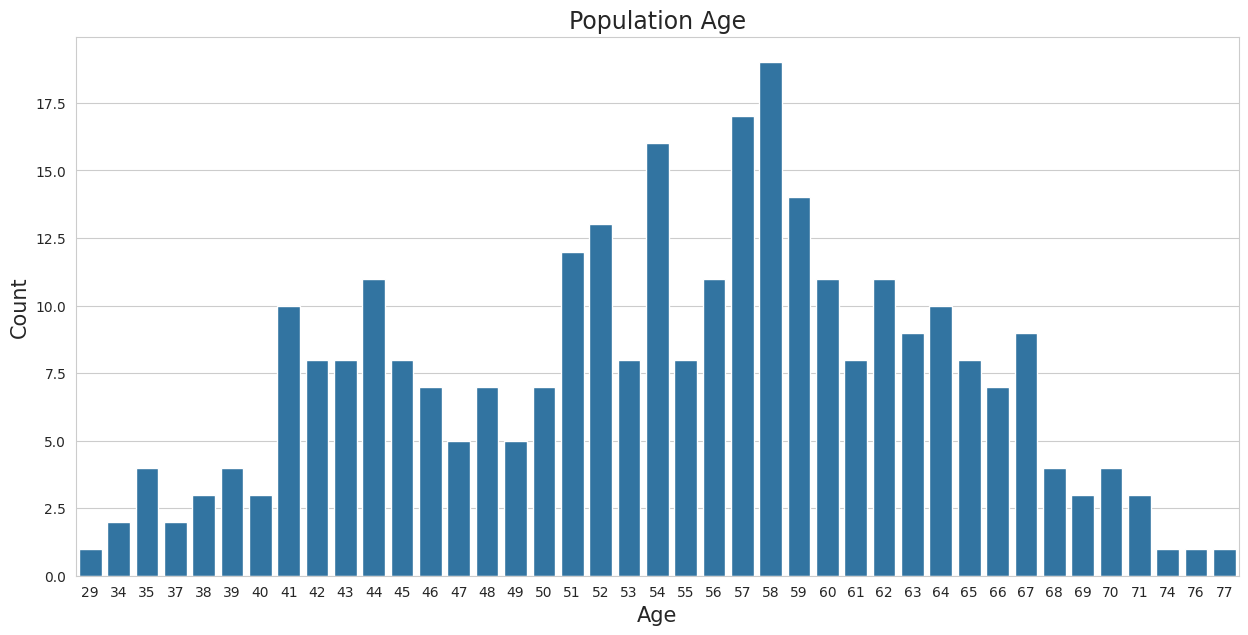

In [10]:
#Countplot Creation of Population Age using MatplotLib and Seaborn

plt.figure(figsize=(15,7))
sns.countplot(x='age', data=data)
plt.title('Population Age', fontsize=17)
plt.xlabel('Age', fontsize=15)
plt.ylabel('Count', fontsize=15)
plt.show()

###### -> In this section, the best analysis can be divided into the elderly,middle-aged, young people by looking at the age ranges.

In [11]:
#Statistical Analysis

Min_Age=data['age'].min()
Max_Age=data['age'].max()
Mean_Age=data['age'].mean()
print("Minimum Age =",Min_Age)
print("Maximum Age =",Max_Age)
print("Mean Age =",Mean_Age)

Minimum Age = 29
Maximum Age = 77
Mean Age = 54.366336633663366


In [12]:
#Categorical Analysis

Young_Ages=data[(data['age']>=29) & (data['age']<40)]
Middle_Ages=data[(data['age']>=40) & (data['age']<55)]
Elderly_Ages=data[(data['age']>55)]
print('Young Ages =',len(Young_Ages))
print('Middle Ages =',len(Middle_Ages))
print('Elderly Ages =',len(Elderly_Ages))

Young Ages = 16
Middle Ages = 128
Elderly Ages = 151


/tmp/ipykernel_6806/3903353695.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Young_Ages','Middle_Ages','Elderly_Ages'], y=[len(Young_Ages), len(Middle_Ages), len(Elderly_Ages)], palette='YlGn_r')


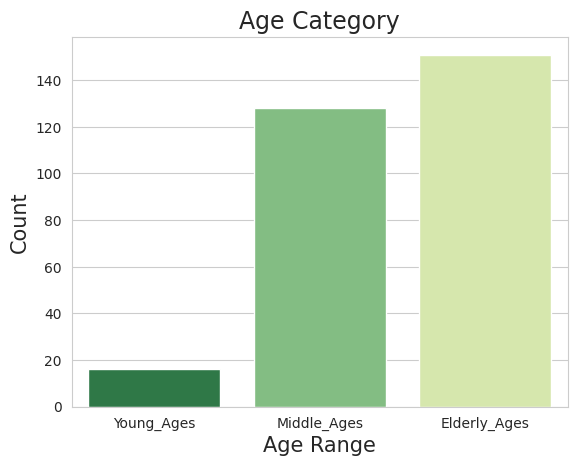

In [13]:
#Bar Plot Creation of Age Category using MatplotLib and Seaborn

sns.barplot(x=['Young_Ages','Middle_Ages','Elderly_Ages'], y=[len(Young_Ages), len(Middle_Ages), len(Elderly_Ages)], palette='YlGn_r')
plt.title('Age Category', fontsize=17)
plt.xlabel('Age Range', fontsize=15)
plt.ylabel('Count', fontsize=15)
plt.show()

In [14]:
#Converting Numerical Data into Categorical Data

def gender(row):
    if row==1:
        return 'Male'
    elif row==0:
        return 'Female'

In [15]:
#Applying converted data into our dataset with new column - sex1

data['sex1']=data['sex'].apply(gender)
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,Heart_Disease,sex1
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1,Presence,Male
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1,Presence,Male
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1,Presence,Female
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1,Presence,Male
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1,Presence,Female


In [16]:
#Converting Numerical Data into Categorical Data

def age_range(row):
    if row>=29 and row<40:
        return 'Young Age'
    elif row>=40 and row<55:
        return 'Middle Age'
    elif row>55:
        return 'Elder Age'

In [17]:
#Applying converted data into our dataset with new column - Age_Range

data['Age_Range']=data['age'].apply(age_range)
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,Heart_Disease,sex1,Age_Range
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1,Presence,Male,Elder Age
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1,Presence,Male,Young Age
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1,Presence,Female,Middle Age
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1,Presence,Male,Elder Age
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1,Presence,Female,Elder Age


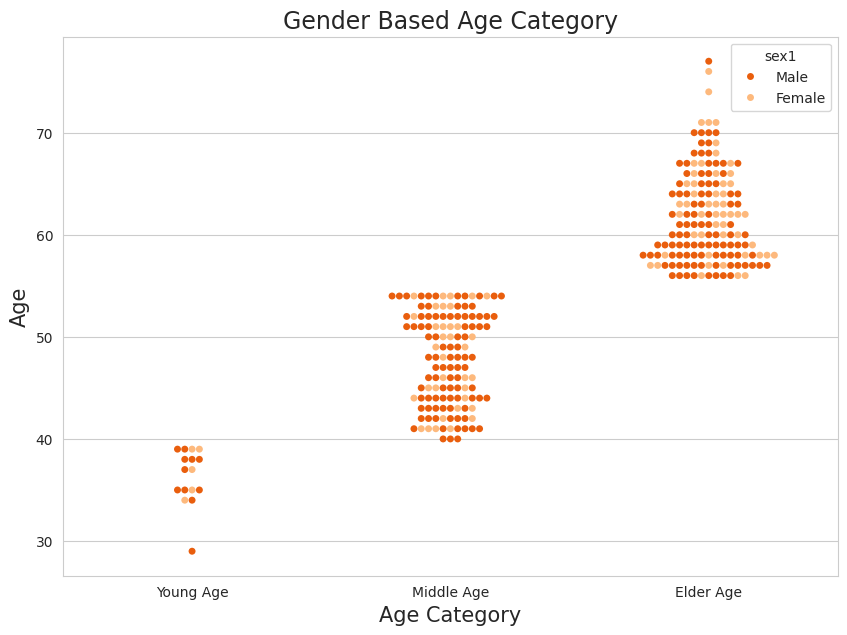

In [18]:
#Swarm Plot Creation of Gender Based Age Category using MatplotLib and Seaborn

plt.figure(figsize=(10,7))
sns.swarmplot(x='Age_Range', y='age', hue='sex1', data=data, order=['Young Age','Middle Age','Elder Age'], palette='Oranges_r')
plt.title('Gender Based Age Category', fontsize=17)
plt.xlabel('Age Category', fontsize=15)
plt.ylabel('Age', fontsize=15)
plt.show()

###### -> In Our Population Number Of Males are more in Middle Age Category and Females are more in Elder Age Category

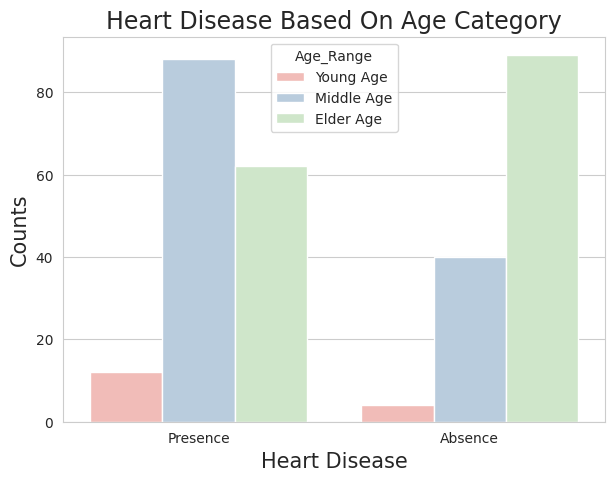

In [19]:
#Count Plot Creation of Heart Disease Based On Age Category using MatplotLib and Seaborn

plt.figure(figsize=(7,5))
hue_order=['Young Age', 'Middle Age', 'Elder Age']
sns.countplot(x='Heart_Disease', hue='Age_Range', data=data, order=['Presence','Absence'], hue_order=hue_order, palette='Pastel1')
plt.title('Heart Disease Based On Age Category', fontsize=17)
plt.xlabel('Heart Disease', fontsize=15)
plt.ylabel('Counts', fontsize=15)
plt.show()

###### -> Elder Age People are most affected by Heart Disease AND Middle Age People are mostly FREE from any kind of Heart Disease

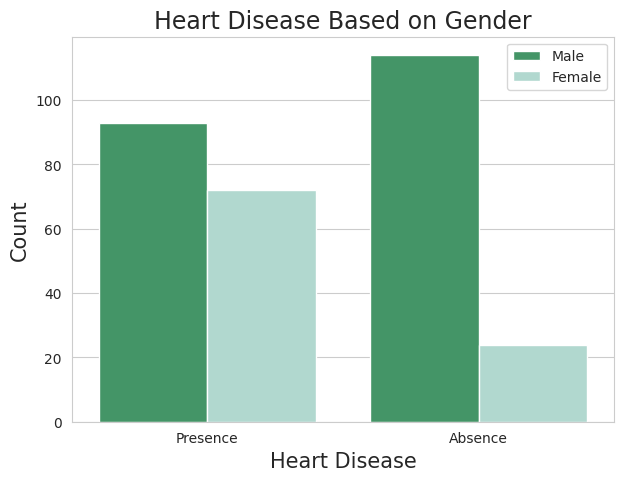

In [20]:
#Count Plot Creation of Heart Disease Based on Gender using MatplotLib and Seaborn

plt.figure(figsize=(7,5))
sns.countplot(x=data['Heart_Disease'], hue='sex1', data=data, palette='BuGn_r')
plt.xlabel('Heart Disease', fontsize=15)
plt.ylabel('Count',fontsize=15)
plt.legend(labels=['Male','Female'])
plt.title('Heart Disease Based on Gender',fontsize=17)
plt.show()

###### -> We can see that Males are more prone to Heart Disease

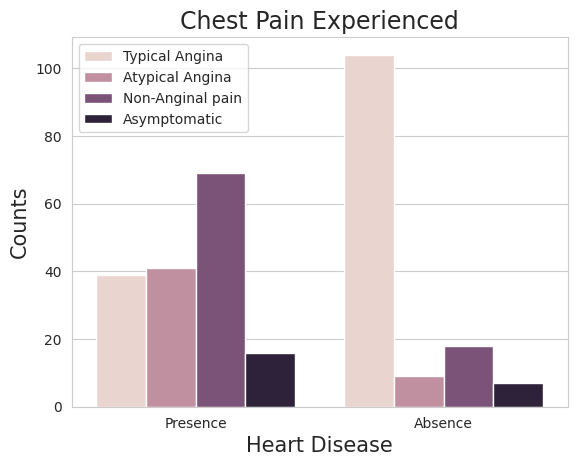

In [21]:
#Count Plot Creation of Chest Pain Experienced using MatplotLib and Seaborn

sns.countplot(x=data['Heart_Disease'], hue='cp', data=data, order=['Presence','Absence'])
plt.title('Chest Pain Experienced', fontsize=17)
plt.xlabel('Heart Disease',fontsize=15)
plt.ylabel('Counts',fontsize=15)
plt.legend(labels=['Typical Angina','Atypical Angina','Non-Anginal pain','Asymptomatic'])
plt.show()

###### -> It seems people having asymptomatic chest pain have a higher chance of heart disease

###### -> Asymptomatic Chest pain means neither causing nor exhibiting symptoms of Heart disease.

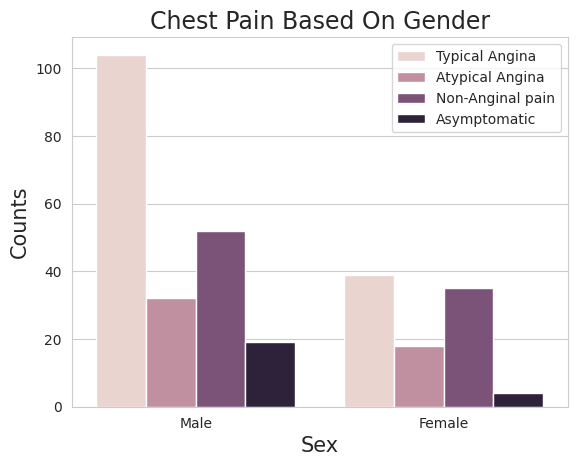

In [22]:
#Count Plot Creation of Chest Pain Based On Gender using MatplotLib and Seaborn

sns.countplot(x=data['sex1'], hue='cp', data=data)
plt.title('Chest Pain Based On Gender', fontsize=17)
plt.xlabel('Sex', fontsize=15)
plt.ylabel('Counts', fontsize=15)
plt.legend(labels=['Typical Angina','Atypical Angina','Non-Anginal pain','Asymptomatic'])
plt.show()

###### -> We can see that a higher number of men are suffering from Asymptomatic type of Chest Pain

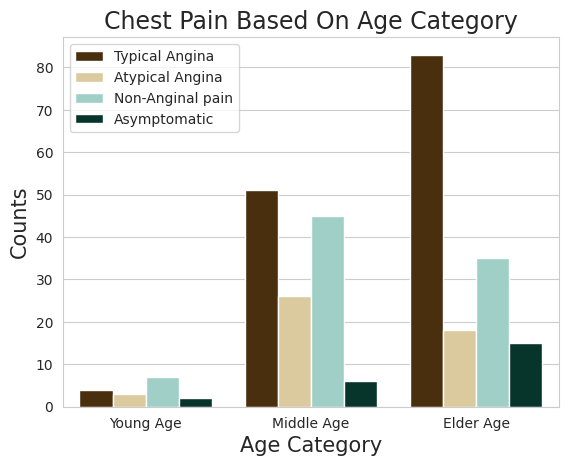

In [23]:
#Count Plot Creation of Chest Pain Based On Age Category using MatplotLib and Seaborn

sns.countplot(x=data['Age_Range'], hue='cp', data=data, order=['Young Age', 'Middle Age', 'Elder Age'], palette='BrBG')
plt.title('Chest Pain Based On Age Category', fontsize=17)
plt.xlabel('Age Category', fontsize=15)
plt.ylabel('Counts', fontsize=15)
plt.legend(labels=['Typical Angina','Atypical Angina','Non-Anginal pain','Asymptomatic'])
plt.show()

###### -> There is very high number of Asymptomatic Pain in Elderly age Category

/tmp/ipykernel_6806/3738778419.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='sex1', y='trestbps', data=data, palette='plasma')


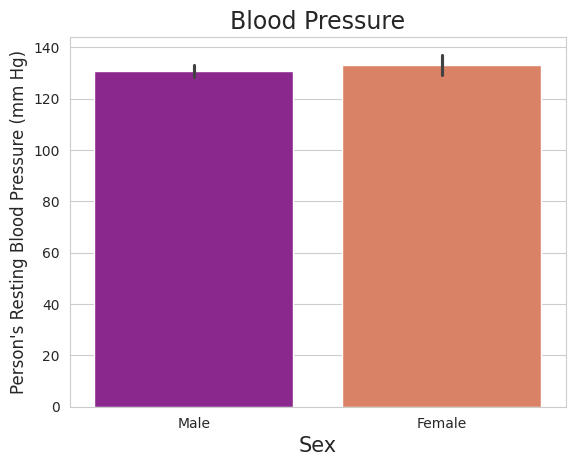

In [24]:
#Bar Plot Creation of Person's Resting Blood Pressure (mm Hg) using MatplotLib and Seaborn

sns.barplot(x='sex1', y='trestbps', data=data, palette='plasma')
plt.title("Blood Pressure", fontsize=17)
plt.xlabel('Sex',fontsize=15)
plt.ylabel("Person's Resting Blood Pressure (mm Hg)", fontsize=12)
plt.show()

###### -> Blood Pressure Rate is almost equal in Males and Females

/tmp/ipykernel_6806/2623607158.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='sex1', y='chol', data=data, palette='turbo')


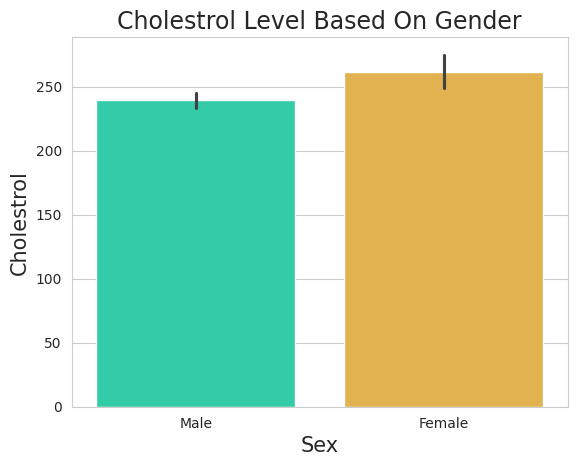

In [25]:
#Bar Plot Creation of Cholestrol Level Based On Gender using MatplotLib and Seaborn

sns.barplot(x='sex1', y='chol', data=data, palette='turbo')
plt.title("Cholestrol Level Based On Gender", fontsize=17)
plt.xlabel('Sex',fontsize=15)
plt.ylabel("Cholestrol", fontsize=15)
plt.show()

###### -> females have little bit of higher cholesterol than males

/tmp/ipykernel_6806/2825866973.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Heart_Disease', y='chol', data=data, palette='ocean_r')


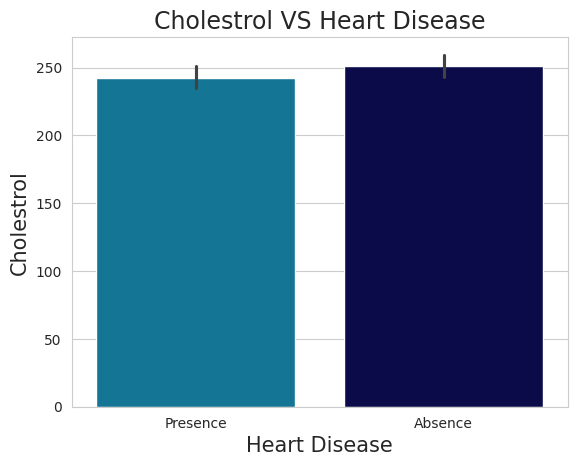

In [26]:
#Bar Plot Creation of Cholestrol VS Heart Disease using MatplotLib and Seaborn

sns.barplot(x='Heart_Disease', y='chol', data=data, palette='ocean_r')
plt.title('Cholestrol VS Heart Disease', fontsize=17)
plt.xlabel('Heart Disease', fontsize=15)
plt.ylabel('Cholestrol', fontsize=15)
plt.show()

###### -> Higher Cholestrol Level results Chances Of Heart Disease

/tmp/ipykernel_6806/2124966136.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Heart_Disease', y='trestbps', data=data, palette='tab20b_r')


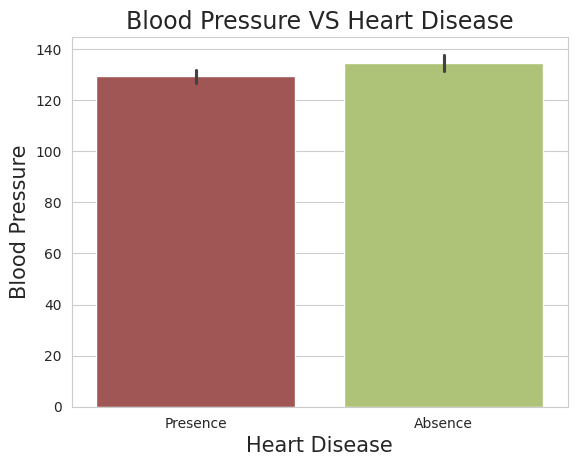

In [27]:
#Bar Plot Creation of Blood Pressure VS Heart Disease using MatplotLib and Seaborn

sns.barplot(x='Heart_Disease', y='trestbps', data=data, palette='tab20b_r')
plt.title('Blood Pressure VS Heart Disease', fontsize=17)
plt.xlabel('Heart Disease', fontsize=15)
plt.ylabel('Blood Pressure', fontsize=15)
plt.show()

###### -> Higher Blood Pressure Level results Chances Of Heart Disease

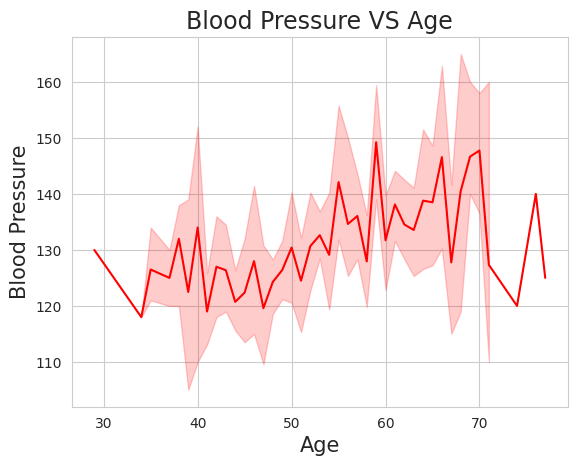

In [28]:
#Line Plot Creation of Blood Pressure VS Age using MatplotLib and Seaborn

sns.lineplot(x='age', y='trestbps', data=data, color='r')
plt.title('Blood Pressure VS Age', fontsize=17)
plt.xlabel('Age', fontsize=15)
plt.ylabel('Blood Pressure', fontsize=15)
plt.show()

###### -> Here we can observe that Blood Pressure increases between age of 50 to 60 and somehow continue the pattern till 70

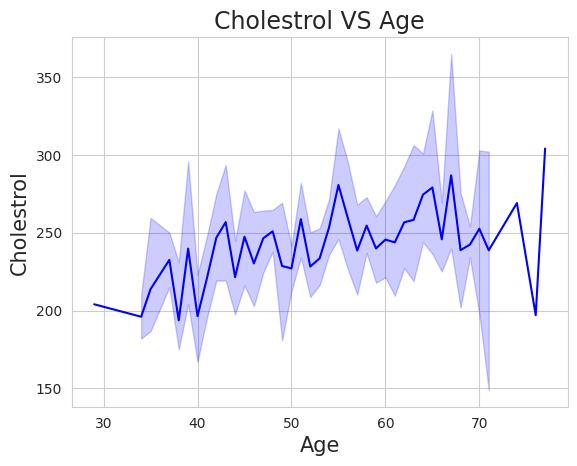

In [29]:
#Line Plot Creation of Cholestrol VS Age using MatplotLib and Seaborn

sns.lineplot(x='age', y='chol', data=data, color='b')
plt.title('Cholestrol VS Age', fontsize=17)
plt.xlabel('Age', fontsize=15)
plt.ylabel('Cholestrol', fontsize=15)
plt.show()

###### -> Similarly Cholestrol Increasing in the age group of 50-60

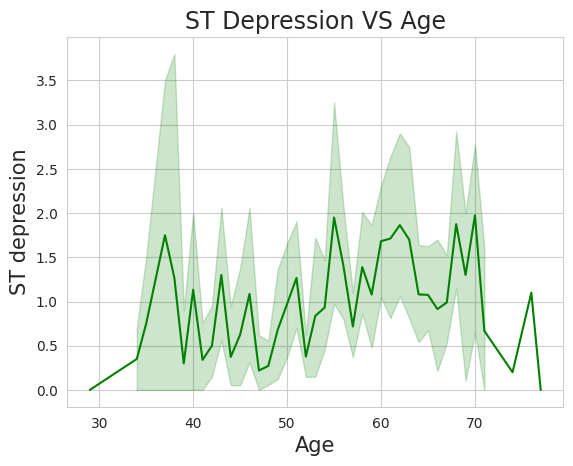

In [30]:
#Line Plot Creation of ST Depression VS Age using MatplotLib and Seaborn

sns.lineplot(x='age', y='oldpeak', data=data, color='g')
plt.title('ST Depression VS Age', fontsize=17)
plt.xlabel('Age', fontsize=15)
plt.ylabel('ST depression', fontsize=15)
plt.show()

###### -> we can observe from here that ST depression mostly increases bw the age group of 30-40

###### -> ST depression refers to a finding on an electrocardiogram, wherein the trace in the ST segment is abnormally low below the baseline.

/tmp/ipykernel_6806/201252497.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='sex1', y='oldpeak', data=data, palette='twilight_r')


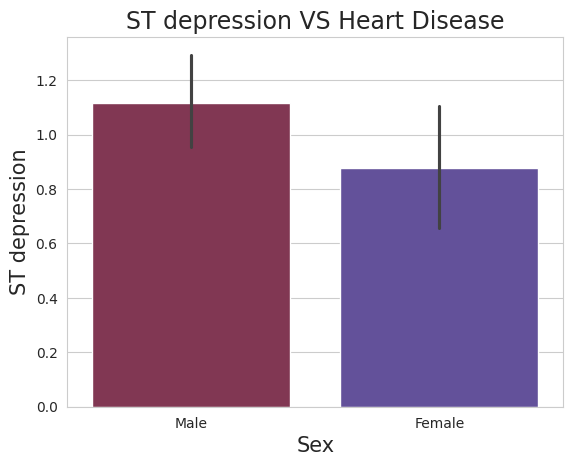

In [31]:
#Bar Plot Creation of ST depression VS Heart Disease using MatplotLib and Seaborn

sns.barplot(x='sex1', y='oldpeak', data=data, palette='twilight_r')
plt.title('ST depression VS Heart Disease', fontsize=17)
plt.xlabel('Sex', fontsize=15)
plt.ylabel('ST depression', fontsize=15)
plt.show()

###### -> More Males are prone to ST depression as compare to females

/tmp/ipykernel_6806/2959183411.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Heart_Disease', y='exang', data=data, palette='viridis')


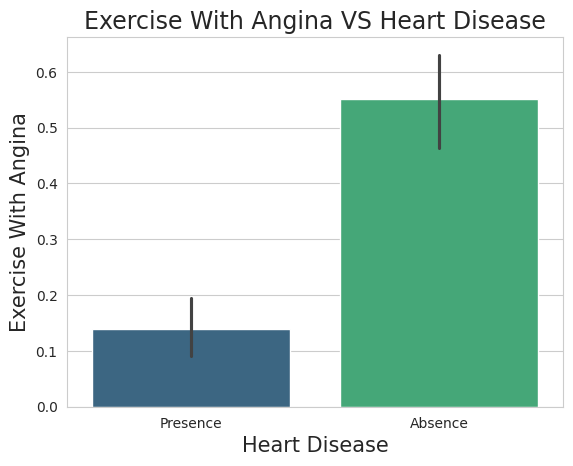

In [32]:
#Bar Plot Creation of Exercise With Angina VS Heart Disease using MatplotLib and Seaborn

sns.barplot(x='Heart_Disease', y='exang', data=data, palette='viridis')
plt.title('Exercise With Angina VS Heart Disease', fontsize=17)
plt.xlabel('Heart Disease', fontsize=15)
plt.ylabel('Exercise With Angina', fontsize=15)
plt.show()

###### -> If you suffer from Angina, you may be concerned that exercise will make your symptoms worse.

/tmp/ipykernel_6806/389153480.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='sex1', y='exang', data=data, palette='binary_r')


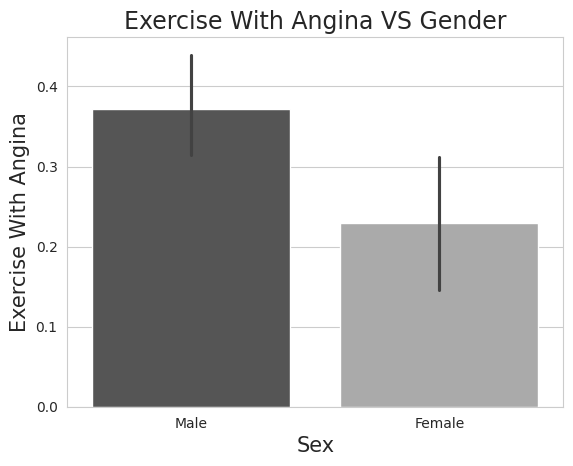

In [33]:
#Bar Plot Creation of Exercise With Angina VS Gender using MatplotLib and Seaborn

sns.barplot(x='sex1', y='exang', data=data, palette='binary_r')
plt.title('Exercise With Angina VS Gender', fontsize=17)
plt.xlabel('Sex', fontsize=15)
plt.ylabel('Exercise With Angina', fontsize=15)
plt.show()

###### -> Males have have high Exercise Angina

###### -> A type of chest pain caused by reduced blood flow to the heart.

/tmp/ipykernel_6806/3171021298.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y='fbs', x='sex1', data=data, palette='hsv')


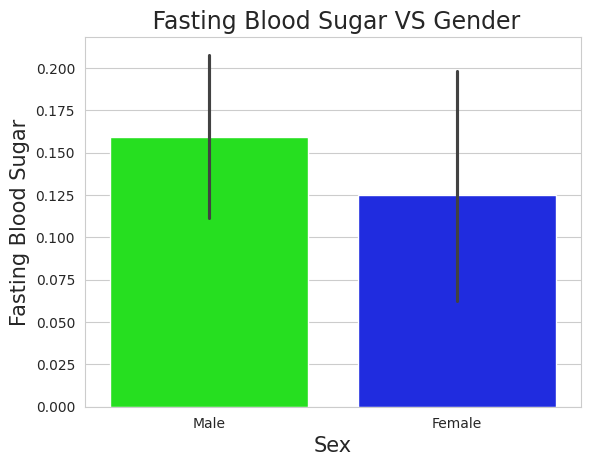

In [34]:
#Bar Plot Creation of Fasting Blood Sugar VS Gender using MatplotLib and Seaborn

sns.barplot(y='fbs', x='sex1', data=data, palette='hsv')
plt.title(' Fasting Blood Sugar VS Gender', fontsize=17)
plt.xlabel('Sex', fontsize=15)
plt.ylabel('Fasting Blood Sugar', fontsize=15)
plt.show()

###### -> Males have high no of Fasting Blood Sugar over 120

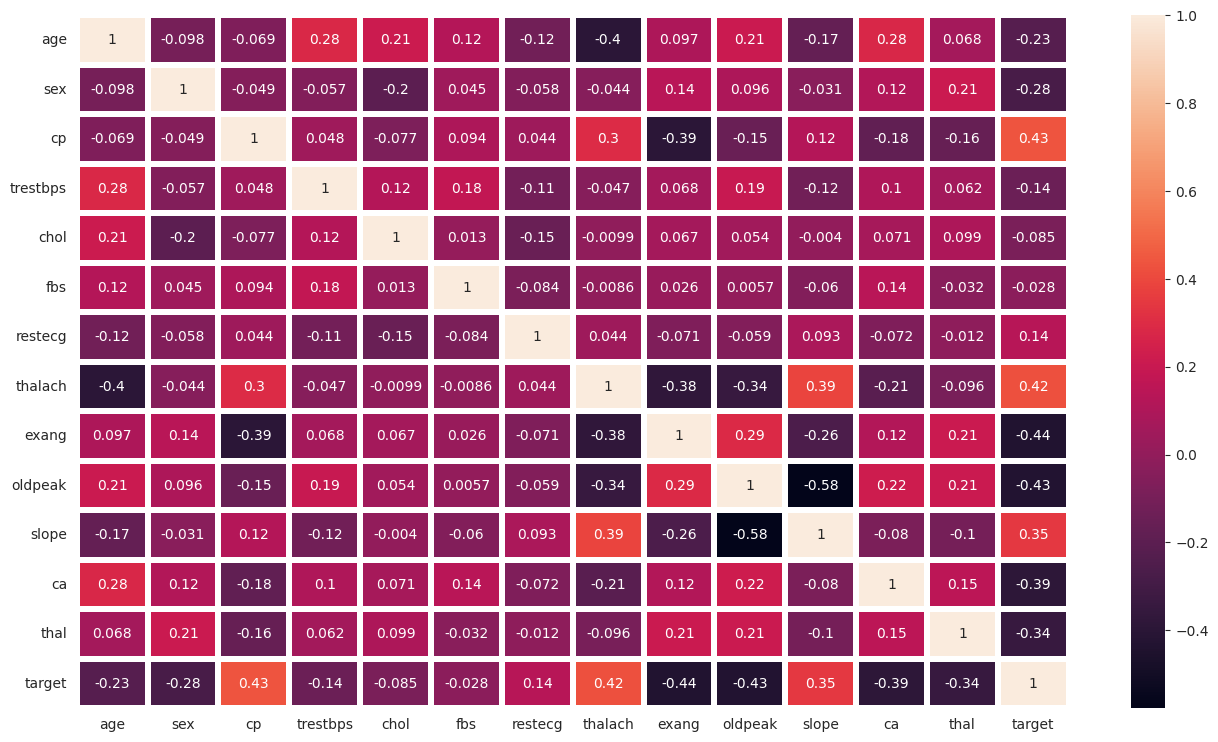

In [35]:
# Drop non-numeric columns
numeric_data = data.select_dtypes(include='number')

# Plot heatmap using only numeric columns
plt.figure(figsize=(16,9))
sns.heatmap(numeric_data.corr(), annot=True, linewidth=3)
plt.show()

## Feature and Target Separation

In [36]:
X = data.drop(columns=['target', 'Heart_Disease','sex1', 'Age_Range'], axis=1)
Y = data["target"]

## Train-Test Split

In [37]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=42)

## Feature Scaling

In [38]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Model Training - Logistic Regression

In [39]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, Y_train)

log_pred = log_model.predict(X_test_scaled)

print("Logistic Regression Accuracy:", accuracy_score(Y_test, log_pred))
print(classification_report(Y_test, log_pred))

Logistic Regression Accuracy: 0.8032786885245902
              precision    recall  f1-score   support

           0       0.86      0.68      0.76        28
           1       0.77      0.91      0.83        33

    accuracy                           0.80        61
   macro avg       0.82      0.79      0.80        61
weighted avg       0.81      0.80      0.80        61



## Model Training - Random Forest

In [40]:
rf_model = RandomForestClassifier(random_state=2)
rf_model.fit(X_train, Y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(Y_test, rf_pred))
print(classification_report(Y_test, rf_pred))

Random Forest Accuracy: 0.7704918032786885
              precision    recall  f1-score   support

           0       0.85      0.61      0.71        28
           1       0.73      0.91      0.81        33

    accuracy                           0.77        61
   macro avg       0.79      0.76      0.76        61
weighted avg       0.79      0.77      0.76        61



## Model Training - Support Vector Machine

In [41]:
svm_model = SVC(kernel="rbf")
svm_model.fit(X_train_scaled, Y_train)

svm_pred = svm_model.predict(X_test_scaled)

print("SVM Accuracy:", accuracy_score(Y_test, svm_pred))
print(classification_report(Y_test, svm_pred))

SVM Accuracy: 0.819672131147541
              precision    recall  f1-score   support

           0       0.90      0.68      0.78        28
           1       0.78      0.94      0.85        33

    accuracy                           0.82        61
   macro avg       0.84      0.81      0.81        61
weighted avg       0.83      0.82      0.82        61



## Model Comparison

In [42]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "SVM"],
    "Accuracy": [
        accuracy_score(Y_test, log_pred),
        accuracy_score(Y_test, rf_pred),
        accuracy_score(Y_test, svm_pred)
    ],
    "Precision": [
        precision_score(Y_test, log_pred),
        precision_score(Y_test, rf_pred),
        precision_score(Y_test, svm_pred)
    ],
    "Recall": [
        recall_score(Y_test, log_pred),
        recall_score(Y_test, rf_pred),
        recall_score(Y_test, svm_pred)
    ],
    "F1 Score": [
        f1_score(Y_test, log_pred),
        f1_score(Y_test, rf_pred),
        f1_score(Y_test, svm_pred)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.803279,0.769231,0.909091,0.833333
1,Random Forest,0.770492,0.731707,0.909091,0.810811
2,SVM,0.819672,0.775000,0.939394,0.849315


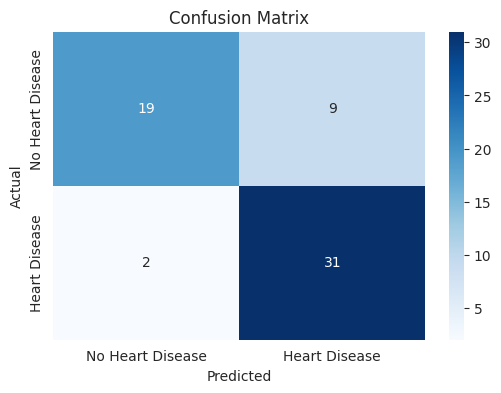

In [43]:
best_pred = svm_pred

cm = confusion_matrix(Y_test, best_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Heart Disease", "Heart Disease"],
    yticklabels=["No Heart Disease", "Heart Disease"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [44]:
sample = X.iloc[[0]]
sample_scaled = scaler.transform(sample)

prediction = svm_model.predict(sample_scaled)

if prediction[0] == 1:
    print("Prediction: Heart Disease Detected")
else:
    print("Prediction: No Heart Disease Detected")

print("Actual:", "Heart Disease" if Y.iloc[0] == 1 else "No Heart Disease")

Prediction: Heart Disease Detected
Actual: Heart Disease


## Conclusion

In this project, heart disease prediction was performed using machine learning.

- Exploratory Data Analysis was performed to understand patterns in the dataset.
- Features such as age, sex, chest pain type, cholesterol, maximum heart rate, and exercise-induced angina were analyzed.
- Logistic Regression, Random Forest, and SVM models were trained and compared.
- SVM achieved the best test accuracy of approximately 81.97%.
- A predictive system was created to classify whether a person has heart disease or not.
- The final SVM model and scaler were saved for deployment.

> Note: This project is for educational purposes only and should not be used for real medical diagnosis.

In [45]:
with open("heart_disease_model.pkl", "wb") as file:
    pickle.dump(svm_model, file)

with open("scaler.pkl", "wb") as file:
    pickle.dump(scaler, file)